# Environment configuration

In [ ]:
%pip install tensorflow[and-cuda] keras torch transformers ipywidgets matplotlib scikit-learn

In [ ]:
import torch
import transformers

device = 'cuda' if torch.cuda.is_available() else 'cpu'
ast_pipeline = transformers.pipeline(
    task='audio-classification',
    model='MIT/ast-finetuned-speech-commands-v2',
    device=device
)

In [63]:
import os
import sys
import shutil
import pickle
import random
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as metrics

In [2]:
random.seed(42)
tf.random.set_seed(42)

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    if os.path.exists('/content/drive/MyDrive/Colab Notebooks/tmp'):
        shutil.copytree(
            src='/content/drive/MyDrive/Colab Notebooks/tmp',
            dst='/content/tmp',
            dirs_exist_ok=True
        )
    drive.flush_and_unmount()

# Dataset download

In [64]:
datasets_dir = 'datasets'
speech_commands_dataset_path = os.path.join(datasets_dir, 'speech_commands_v0.02')

if not os.path.exists(speech_commands_dataset_path):
    keras.utils.get_file(
        fname='tmp.tar.gz',
        origin='http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz',
        extract=True,
        cache_dir='.',
        cache_subdir=datasets_dir
    )
    os.rename(os.path.join(datasets_dir, 'tmp_extracted'), speech_commands_dataset_path)
    os.remove(os.path.join(datasets_dir, 'tmp.tar.gz'))

2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


# Teacher model inference

In [ ]:
class TeacherDataset(torch.utils.data.Dataset):

    def __init__(self, paths: list[str]) -> None:
        self.paths = paths

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int) -> str:
        return self.paths[index]

In [ ]:
if os.path.exists('tmp/teacher_keyword_dict.pkl'):
    with open('tmp/teacher_keyword_dict.pkl', 'rb') as file:
        teacher_keyword_dict = pickle.load(file)
else:
    audio_paths = []
    for root, _, files in os.walk(speech_commands_dataset_path):
        for file in files:
            if file.endswith('.wav'):
                audio_paths.append(os.path.join(root, file))
    teacher_dataset = TeacherDataset(audio_paths)
    teacher_predictions = ast_pipeline(teacher_dataset, batch_size=128, top_k=1)
    teacher_keyword_dict = {
        audio_path: teacher_prediction[0]['label']
        for audio_path, teacher_prediction in zip(audio_paths, teacher_predictions)
    }
    os.makedirs('tmp', exist_ok=True)
    with open('tmp/teacher_keyword_dict.pkl', 'wb') as file:
        pickle.dump(teacher_keyword_dict, file)

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    shutil.copytree(
        src='/content/tmp',
        dst='/content/drive/MyDrive/Colab Notebooks/tmp',
        dirs_exist_ok=True
    )
    drive.flush_and_unmount()

Mounted at /content/drive


# Preprocessing and augmentation

In [65]:
KEYWORDS_10 = ['up', 'down', 'left', 'right', 'yes', 'no', 'on', 'off', 'go', 'stop']
SILENCE_KEYWORD = '_silence_'
UNKNOWN_KEYWORD = '_unknown_'
KEYWORDS_12 = KEYWORDS_10 + [SILENCE_KEYWORD, UNKNOWN_KEYWORD]
KNOWN_KEYWORD = '_known_'
SILENCE_UNKNOWN_KEYWORD = '_silence_unknown_'


class SpeechCommandsDatasetManager:

    def __init__(
        self,
        dataset_path: str,
        mode: str,
        sample_rate: int = 16000,
        duration: float = 1.0,
        window_length_ms: int = 30,
        window_stride_ms: int = 10,
        num_mfcc: int = 40,
        max_shift_ms: int = 100,
        resample_range: tuple[float, float] = (0.85, 1.15),
        background_volume: float = 0.1,
        num_time_masks: int = 2,
        max_time_mask_size: int = 25,
        num_freq_masks: int = 2,
        max_freq_mask_size: int = 7,
        unknown_ratio: float = 0.18,
        silence_ratio: float = 0.18
    ) -> None:
        if mode not in ['2', '10', '12', '35']:
            raise ValueError("mode must be '2', '10', '12' or '35'")
        self.mode = mode
        self.dataset_path = dataset_path
        self.sample_rate = sample_rate
        self.duration = duration
        self.audio_length = int(sample_rate * duration)
        self.window_length = int(sample_rate * window_length_ms / 1000)
        self.window_stride = int(sample_rate * window_stride_ms / 1000)
        self.num_frames = 1 + (self.audio_length - self.window_length) // self.window_stride
        self.num_mfcc = num_mfcc
        self.max_shift = int(sample_rate * max_shift_ms / 1000)
        self.resample_range = resample_range
        self.background_volume = background_volume
        self.num_time_masks = num_time_masks
        self.max_time_mask_size = max_time_mask_size
        self.num_freq_masks = num_freq_masks
        self.max_freq_mask_size = max_freq_mask_size
        self.unknown_ratio = unknown_ratio
        self.silence_ratio = silence_ratio
        self.all_keywords = self._load_all_keywords()
        if mode == '2':
            self.keywords = [KNOWN_KEYWORD, SILENCE_UNKNOWN_KEYWORD]
        elif mode == '10':
            self.keywords = KEYWORDS_10
        elif mode == '12':
            self.keywords = KEYWORDS_12
        else:
            self.keywords = self.all_keywords
        self.val_relative_paths = self._load_split_list('validation_list.txt')
        self.test_relative_paths = self._load_split_list('testing_list.txt')
        self.background_noises = self._load_background_noises()

    def _load_all_keywords(self) -> list[str]:
        keywords = []
        for filename in os.listdir(self.dataset_path):
            if os.path.isdir(os.path.join(self.dataset_path, filename)) and not filename.startswith('_'):
                keywords.append(filename)
        return sorted(keywords)

    def _load_split_list(self, filename: str) -> set:
        file_path = os.path.join(self.dataset_path, filename)
        if not os.path.exists(file_path):
            raise FileNotFoundError(f'{filename} not found in {self.dataset_path}')
        with open(file_path, 'r') as file:
            return set(line.strip() for line in file)

    def _load_background_noises(self) -> tf.Tensor:
        noise_dir = os.path.join(self.dataset_path, '_background_noise_')
        if not os.path.isdir(noise_dir):
            return tf.zeros((1, self.audio_length + 1), dtype=tf.float32)
        audios = []
        for filename in os.listdir(noise_dir):
            if filename.endswith('.wav'):
                audio = tf.io.read_file(os.path.join(noise_dir, filename))
                audio, _ = tf.audio.decode_wav(audio, desired_channels=1)
                audio = tf.squeeze(audio, axis=-1)
                audios.append(audio)
        min_length = min(audio.shape[0] for audio in audios)
        audios = [audio[:min_length] for audio in audios]
        audios = tf.stack(audios)
        return audios

    def build_dataset(
        self,
        split: str,
        batch_size: int,
        return_teacher_keyword: bool = False,
        return_audio: bool = False
    ) -> tf.data.Dataset:
        if split not in ['train', 'val', 'test']:
            raise ValueError("split must be 'train', 'val' or 'test'")
        if return_teacher_keyword and return_audio:
            raise ValueError('return_teacher_keyword and return_audio cannot be True at the same time')
        audio_paths, keywords = self._collect_split(split)
        audio_paths = tf.constant(audio_paths)
        keywords = tf.constant(keywords)
        if return_teacher_keyword:
            teacher_keywords = tf.constant([teacher_keyword_dict[audio_path.numpy().decode('utf-8')] for audio_path in audio_paths], dtype=tf.string)
            dataset = tf.data.Dataset.from_tensor_slices((audio_paths, keywords, teacher_keywords))
        else:
            dataset = tf.data.Dataset.from_tensor_slices((audio_paths, keywords))
        if split == 'train':
            dataset = dataset.shuffle(
                buffer_size=len(audio_paths),
                reshuffle_each_iteration=True
            )

        def process_pipeline(*args: tuple) -> tuple[tf.Tensor, tf.Tensor]:
            if return_teacher_keyword:
                path, keyword, teacher_keyword = args
            else:
                path, keyword = args
                teacher_keyword = None
            audio, keyword = self._parse_audio(path, keyword)
            if split == 'train':
                audio, keyword = self._augment_audio(audio, keyword)
            mfcc, keyword = self._compute_mfcc(audio, keyword)
            if split == 'train':
                mfcc, keyword = self._augment_mfcc(mfcc, keyword)
            mfcc = tf.ensure_shape(mfcc, [self.num_frames, self.num_mfcc])
            if return_teacher_keyword:
                return ((mfcc, keyword), teacher_keyword)
            elif return_audio:
                return ((mfcc, keyword), audio)
            else:
                return (mfcc, keyword)

        dataset = dataset.map(process_pipeline, num_parallel_calls=tf.data.AUTOTUNE)
        if split == 'train':
            dataset = dataset.repeat()
        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        return dataset

    def _collect_split(self, split: str) -> tuple[list[str], list[str]]:
        audio_paths = []
        keywords = []
        for keyword in self.all_keywords:
            keyword_dir = os.path.join(self.dataset_path, keyword)
            for filename in os.listdir(keyword_dir):
                if filename.endswith('.wav'):
                    relative_path = f'{keyword}/{filename}'
                    if relative_path in self.val_relative_paths:
                        file_split = 'val'
                    elif relative_path in self.test_relative_paths:
                        file_split = 'test'
                    else:
                        file_split = 'train'
                    if file_split == split:
                        audio_paths.append(os.path.join(keyword_dir, filename))
                        keywords.append(keyword)
        if self.mode == '2':
            audio_paths, keywords = self._process_split_mode_2(audio_paths, keywords)
        elif self.mode == '10':
            audio_paths, keywords = self._process_split_mode_10(audio_paths, keywords)
        elif self.mode == '12':
            audio_paths, keywords = self._process_split_mode_12(audio_paths, keywords)
        return audio_paths, keywords
    
    def _process_split_mode_2(self, audio_paths: list[str], keywords: list[str]) -> tuple[list[str], list[str]]:
        # Using the SpeechCommandsDatasetManager default parameters, we can expect that:
        # - 41% of labels are KNOWN_KEYWORD
        # - 59% of labels are SILENCE_UNKNOWN_KEYWORD
        # - 18% of audios labeled SILENCE_UNKNOWN_KEYWORD contain silence
        keywords_10_audio_paths = []
        unknown_audio_paths = []
        keywords_10 = set(KEYWORDS_10)
        for audio_path, keyword in zip(audio_paths, keywords):
            if keyword in keywords_10:
                keywords_10_audio_paths.append(audio_path)
            else:
                unknown_audio_paths.append(audio_path)
        silent_length = int(self.silence_ratio * len(unknown_audio_paths) // (1 - self.silence_ratio))
        unknown_audio_paths += [''] * silent_length
        processed_audio_paths = keywords_10_audio_paths + unknown_audio_paths
        processed_keywords = [KNOWN_KEYWORD] * len(keywords_10_audio_paths) + [SILENCE_UNKNOWN_KEYWORD] * len(unknown_audio_paths)
        return processed_audio_paths, processed_keywords

    def _process_split_mode_10(self, audio_paths: list[str], keywords: list[str]) -> tuple[list[str], list[str]]:
        processed_audio_paths = []
        processed_keywords = []
        keywords_10 = set(KEYWORDS_10)
        for audio_path, keyword in zip(audio_paths, keywords):
            if keyword in keywords_10:
                processed_audio_paths.append(audio_path)
                processed_keywords.append(keyword)
        return processed_audio_paths, processed_keywords

    def _process_split_mode_12(self, audio_paths: list[str], keywords: list[str]) -> tuple[list[str], list[str]]:
        # Using the SpeechCommandsDatasetManager default parameters, we can expect that:
        # - 18% of labels are UNKNOWN_KEYWORD
        # - 18% of labels are SILENCE_KEYWORD
        # - 64% of labels are the keywords in KEYWORDS_10
        processed_audio_paths = []
        processed_keywords = []
        unknown_audio_paths = []
        keywords_10 = set(KEYWORDS_10)
        for audio_path, keyword in zip(audio_paths, keywords):
            if keyword in keywords_10:
                processed_audio_paths.append(audio_path)
                processed_keywords.append(keyword)
            else:
                unknown_audio_paths.append(audio_path)
        unknown_length = int(self.unknown_ratio * len(processed_audio_paths) // (1 - self.unknown_ratio - self.silence_ratio))
        silent_length = int(self.silence_ratio * len(processed_audio_paths) // (1 - self.unknown_ratio - self.silence_ratio))
        processed_audio_paths += random.sample(unknown_audio_paths, unknown_length)
        processed_keywords += [UNKNOWN_KEYWORD] * unknown_length
        processed_audio_paths += [''] * silent_length
        processed_keywords += [SILENCE_KEYWORD] * silent_length
        return processed_audio_paths, processed_keywords

    def _parse_audio(self, audio_path: tf.Tensor, keyword: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
        if keyword == SILENCE_KEYWORD or (audio_path == '' and keyword == SILENCE_UNKNOWN_KEYWORD):
            audio = tf.zeros(self.audio_length, dtype=tf.float32)
            return audio, keyword
        audio = tf.io.read_file(audio_path)
        audio, _ = tf.audio.decode_wav(audio, desired_samples=self.audio_length, desired_channels=1)
        audio = tf.squeeze(audio, axis=-1)
        if tf.shape(audio)[0] < self.audio_length:
            audio = tf.pad(audio, [[0, self.audio_length - tf.shape(audio)[0]]])
        return audio, keyword

    def _augment_audio(self, audio: tf.Tensor, keyword: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
        audio = self._random_time_shift(audio)
        audio = self._random_resample(audio)
        audio = self._random_background_noise(audio)
        return audio, keyword

    def _random_time_shift(self, audio: tf.Tensor) -> tf.Tensor:
        shift = tf.random.uniform([], -self.max_shift, self.max_shift + 1, dtype=tf.int32)
        shifted_audio = tf.roll(audio, shift=shift, axis=0)
        audio_length = tf.shape(audio)[0]
        mask = tf.cond(
            shift >= 0,
            lambda: tf.concat([tf.zeros(shift, dtype=audio.dtype), tf.ones(audio_length - shift, dtype=audio.dtype)], axis=0),
            lambda: tf.concat([tf.ones(audio_length + shift, dtype=audio.dtype), tf.zeros(-shift, dtype=audio.dtype)], axis=0)
        )
        return shifted_audio * mask

    def _random_background_noise(self, audio: tf.Tensor) -> tf.Tensor:
        noise_index = tf.random.uniform([], 0, tf.shape(self.background_noises)[0], dtype=tf.int32)
        noise = self.background_noises[noise_index]
        noise_length = tf.shape(noise)[0]
        audio_length = tf.shape(audio)[0]
        start_index = tf.random.uniform([], 0, noise_length - audio_length, dtype=tf.int32)
        return audio + self.background_volume * noise[start_index:start_index + audio_length]

    def _random_resample(self, audio: tf.Tensor) -> tf.Tensor:
        resample_rate = tf.random.uniform([], self.resample_range[0], self.resample_range[1], dtype=tf.float32)
        audio_length = tf.shape(audio)[0]
        resampled_audio_length = tf.cast(tf.cast(audio_length, tf.float32) * resample_rate, tf.int32)
        resampled_audio = tf.image.resize(
            tf.reshape(audio, [1, -1, 1]), # Shape: (height, width, channels)
            size=[1, resampled_audio_length] # [new_height, new_width]
        )
        resampled_audio = tf.squeeze(resampled_audio)
        if resampled_audio_length < audio_length:
            pad_length = audio_length - resampled_audio_length
            left_pad = pad_length // 2
            right_pad = pad_length - left_pad
            resampled_audio = tf.pad(resampled_audio, [[left_pad, right_pad]])
        elif resampled_audio_length > audio_length:
            start_index = (resampled_audio_length - audio_length) // 2
            resampled_audio = resampled_audio[start_index:start_index + audio_length]
        return resampled_audio

    def _compute_mfcc(self, audio: tf.Tensor, keyword: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
        stft = tf.signal.stft(audio, frame_length=self.window_length, frame_step=self.window_stride)
        spectrogram = tf.abs(stft)
        linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=2 * self.num_mfcc,
            num_spectrogram_bins= tf.shape(stft)[-1],
            sample_rate=self.sample_rate,
            lower_edge_hertz=80.0,
            upper_edge_hertz=7600.0
        )
        mel_spectrograms = spectrogram @ linear_to_mel_weight_matrix
        log_mel_spectrograms = tf.math.log(mel_spectrograms + 1e-6)
        mfcc = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrograms)
        mfcc = mfcc[:, :self.num_mfcc]
        return mfcc, keyword

    def _augment_mfcc(self, mfcc: tf.Tensor, keyword: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
        mfcc = self._spec_augment(mfcc)
        return mfcc, keyword

    def _spec_augment(self, mfcc: tf.Tensor) -> tf.Tensor:
        for _ in range(self.num_time_masks): # Time masking
            time_mask_size = tf.random.uniform([], 0, self.max_time_mask_size + 1, dtype=tf.int32)
            time_mask_start = tf.random.uniform([], 0, tf.shape(mfcc)[0] - time_mask_size, dtype=tf.int32)
            mfcc = tf.concat([
                mfcc[:time_mask_start],
                tf.zeros((time_mask_size, tf.shape(mfcc)[1]), dtype=mfcc.dtype),
                mfcc[time_mask_start + time_mask_size:]
            ], axis=0)
        for _ in range(self.num_freq_masks): # Frequency masking
            freq_mask_size = tf.random.uniform([], 0, self.max_freq_mask_size + 1, dtype=tf.int32)
            freq_mask_start = tf.random.uniform([], 0, tf.shape(mfcc)[1] - freq_mask_size, dtype=tf.int32)
            mfcc = tf.concat([
                mfcc[:, :freq_mask_start],
                tf.zeros((tf.shape(mfcc)[0], freq_mask_size), dtype=mfcc.dtype),
                mfcc[:, freq_mask_start + freq_mask_size:]
            ], axis=1)
        return mfcc

    def get_num_train_samples(self) -> int:
        count_all_keywords = 0
        count_keywords = 0
        keyword_filter = set(self.keywords) if self.mode != '2' else set(KEYWORDS_10)
        for keyword in self.all_keywords:
            keyword_dir = os.path.join(self.dataset_path, keyword)
            for filename in os.listdir(keyword_dir):
                if filename.endswith('.wav'):
                    relative_path = f'{keyword}/{filename}'
                    if relative_path not in self.val_relative_paths and relative_path not in self.test_relative_paths:
                        count_all_keywords += 1
                        if keyword in keyword_filter:
                            count_keywords += 1
        if self.mode == '2':
            count_keywords = count_all_keywords + int(self.silence_ratio * (count_all_keywords - count_keywords) // (1 - self.silence_ratio))
        if self.mode == '12':
            unknown_length = int(self.unknown_ratio * count_keywords // (1 - self.unknown_ratio - self.silence_ratio))
            silent_length = int(self.silence_ratio * count_keywords // (1 - self.unknown_ratio - self.silence_ratio))
            count_keywords += unknown_length + silent_length
        return count_keywords

In [70]:
{mode: SpeechCommandsDatasetManager(dataset_path=speech_commands_dataset_path, mode=mode).get_num_train_samples() for mode in ['2', '10', '12', '35']}

{'2': 96712, '10': 30769, '12': 48075, '35': 84843}

In [ ]:
speech_commands_dataset_manager = SpeechCommandsDatasetManager(dataset_path=speech_commands_dataset_path, mode='12')
train_dataset = speech_commands_dataset_manager.build_dataset(split='train', batch_size=32, return_audio=True)
val_dataset = speech_commands_dataset_manager.build_dataset(split='val', batch_size=32, return_audio=True)
test_dataset = speech_commands_dataset_manager.build_dataset(split='test', batch_size=32, return_audio=True)

In [13]:
(mfccs, keywords), audio = list(train_dataset.take(1))[0]
mfccs.shape, keywords.shape, audio.shape

(TensorShape([32, 98, 40]), TensorShape([32]), TensorShape([32, 16000]))

# Model

In [ ]:
class EmbeddingBlockKWT(keras.Layer):

    def __init__(self, d: int, **kwargs) -> None:
        super().__init__(**kwargs)
        self.d = d # Embedding dimension

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({'d': self.d})
        return config

    def build(self, input_shape: tf.TensorShape) -> None:
        T = input_shape[1]
        F = input_shape[2]
        self.W_0 = self.add_weight(shape=(F, self.d))
        self.X_class = self.add_weight(shape=(1, 1, self.d))
        self.X_pos = self.add_weight(shape=(1, T + 1, self.d))

    def call(self, mfccs: tf.Tensor) -> tf.Tensor:
        batch_size = tf.shape(mfccs)[0]
        X_class_tiled = tf.tile(self.X_class, [batch_size, 1, 1]) # Shape: (batch_size, 1, d)
        # X_pos_tiled = tf.tile(self.X_pos, [batch_size, 1, 1]) # Shape: (batch_size, T + 1, d)
        X_1 = mfccs @ self.W_0 # Shape: (batch_size, T, d)
        X_0 = tf.concat([X_class_tiled, X_1], axis=1) + self.X_pos # Shape: (batch_size, T + 1, d)
        return X_0

In [ ]:
class EmbeddingBlockKWTDistilled(keras.Layer):

    def __init__(self, d: int, **kwargs) -> None:
        super().__init__(**kwargs)
        self.d = d # Embedding dimension

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({'d': self.d})
        return config

    def build(self, input_shape: tf.TensorShape) -> None:
        T = input_shape[1]
        F = input_shape[2]
        self.W_0 = self.add_weight(shape=(F, self.d))
        self.X_class = self.add_weight(shape=(1, 1, self.d))
        self.X_dist = self.add_weight(shape=(1, 1, self.d))
        self.X_pos = self.add_weight(shape=(1, T + 2, self.d))

    def call(self, mfccs: tf.Tensor) -> tf.Tensor:
        batch_size = tf.shape(mfccs)[0]
        X_class_tiled = tf.tile(self.X_class, [batch_size, 1, 1])
        X_dist_tiled = tf.tile(self.X_dist, [batch_size, 1, 1])
        X_1 = mfccs @ self.W_0
        X_0 = tf.concat([X_class_tiled, X_dist_tiled, X_1], axis=1) + self.X_pos
        return X_0

In [ ]:
class TransformerBlockKWT(keras.Layer):

    def __init__(self, k: int, **kwargs) -> None:
        super().__init__(**kwargs)
        self.k = k # Number of attention heads
        self.d = 64 * k # Embedding dimension
        self.d_h = 64 # Dimension of each attention head
        self.msa = layers.MultiHeadAttention(
            num_heads=self.k,
            key_dim=self.d_h,
            use_bias=False
        )
        self.ln1 = layers.LayerNormalization()
        self.mlp = keras.Sequential([
            layers.Dense(4 * self.d, activation='gelu'),
            layers.Dense(self.d)
        ])
        self.ln2 = layers.LayerNormalization()

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({'k': self.k})
        return config

    def call(self, embeddings: tf.Tensor, training: bool = None) -> tf.Tensor:
        msa_out = self.msa(embeddings, embeddings, embeddings, training=training)
        x_tilde = self.ln1(msa_out + embeddings)
        mlp_out = self.mlp(x_tilde, training=training)
        x = self.ln2(mlp_out + x_tilde)
        return x

In [ ]:
class KeywordTransformer(keras.Model):

    def __init__(self, num_classes: int, k: int, depth: int = 12, **kwargs) -> None:
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.k = k
        self.depth = depth
        self.d = 64 * k
        self.embedding_block = EmbeddingBlockKWT(d=self.d)
        self.transformer_blocks = [TransformerBlockKWT(k=k) for _ in range(depth)]
        self.head = layers.Dense(num_classes)

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'k': self.k,
            'depth': self.depth
        })
        return config

    def call(self, mfccs: tf.Tensor, training: bool = None) -> tf.Tensor:
        x = self.embedding_block(mfccs)
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, training=training)
        x = x[:, 0, :] # Extract the class token
        logits = self.head(x)
        return logits

In [ ]:
class KeywordTransformerDistilled(keras.Model):

    def __init__(self, num_classes: int, k: int, depth: int = 12, **kwargs) -> None:
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.k = k
        self.depth = depth
        self.d = 64 * k
        self.embedding_block = EmbeddingBlockKWTDistilled(d=self.d)
        self.transformer_blocks = [TransformerBlockKWT(k=k) for _ in range(depth)]
        self.class_head = layers.Dense(num_classes)
        self.distillation_head = layers.Dense(num_classes)

    def get_config(self) -> dict:
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'k': self.k,
            'depth': self.depth
        })
        return config

    def call(self, mfccs: tf.Tensor, training: bool = None) -> tuple[tf.Tensor, tf.Tensor]:
        x = self.embedding_block(mfccs)
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, training=training)
        class_token = x[:, 0, :]
        distillation_token = x[:, 1, :]
        class_logits = self.class_head(class_token)
        distillation_logits = self.distillation_head(distillation_token)
        return class_logits, distillation_logits

In [19]:
kwt_1 = KeywordTransformer(num_classes=12, k=1, depth=12)
kwt_2 = KeywordTransformer(num_classes=12, k=2, depth=12)
kwt_3 = KeywordTransformer(num_classes=12, k=3, depth=12)

kwt_1(mfccs)
kwt_2(mfccs)
kwt_3(mfccs)

kwt_1.count_params(), kwt_2.count_params(), kwt_3.count_params()

(606476, 2392588, 5358348)

In [20]:
kwt_1_distilled = KeywordTransformerDistilled(num_classes=12, k=1, depth=12)
kwt_2_distilled = KeywordTransformerDistilled(num_classes=12, k=2, depth=12)
kwt_3_distilled = KeywordTransformerDistilled(num_classes=12, k=3, depth=12)

kwt_1_distilled(mfccs)
kwt_2_distilled(mfccs)
kwt_3_distilled(mfccs)

kwt_1_distilled.count_params(), kwt_2_distilled.count_params(), kwt_3_distilled.count_params()

(607384, 2394392, 5361048)

# Training

In [ ]:
speech_commands_dataset_mode = '35'
k = 2

In [22]:
depth = 12

In [23]:
training_steps = 23_000 # epochs * steps_per_epoch
batch_size = 512
learning_rate = 0.001
warmup_epochs = 10
weight_decay = 0.1
label_smoothing = 0.1

patience = 10

In [24]:
speech_commands_dataset_manager = SpeechCommandsDatasetManager(
    dataset_path=speech_commands_dataset_path,
    mode=speech_commands_dataset_mode
)

keyword_encoder = keras.layers.StringLookup(
    output_mode='one_hot',
    vocabulary=speech_commands_dataset_manager.keywords,
    num_oov_indices=0
)

In [25]:
steps_per_epoch = speech_commands_dataset_manager.get_num_train_samples() // batch_size
epochs = training_steps // steps_per_epoch
warmup_steps = warmup_epochs * steps_per_epoch
decay_steps = training_steps - warmup_steps

In [26]:
loss_function = keras.losses.CategoricalCrossentropy(
    from_logits=True,
    label_smoothing=label_smoothing
)

## Training without distillation

In [31]:
cosine_decay = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    warmup_steps=warmup_steps
)
optimizer = keras.optimizers.AdamW(
    learning_rate=cosine_decay,
    weight_decay=weight_decay
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=f'models/kwt_{k}_{speech_commands_dataset_mode}.keras',
    monitor='val_loss',
    save_best_only=True
)

In [32]:
train_dataset = speech_commands_dataset_manager.build_dataset(split='train', batch_size=batch_size)
val_dataset = speech_commands_dataset_manager.build_dataset(split='val', batch_size=batch_size)
test_dataset = speech_commands_dataset_manager.build_dataset(split='test', batch_size=batch_size)

train_dataset = train_dataset.map(
    map_func=lambda mfcc, keyword: (mfcc, keyword_encoder(keyword)),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.map(
    map_func=lambda mfcc, keyword: (mfcc, keyword_encoder(keyword)),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset = test_dataset.map(
    map_func=lambda mfcc, keyword: (mfcc, keyword_encoder(keyword)),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [33]:
model = KeywordTransformer(
    num_classes=len(speech_commands_dataset_manager.keywords),
    k=k,
    depth=depth
)

In [34]:
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=['accuracy']
)
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint],
    shuffle=False
)

Epoch 1/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.0892 - loss: 3.3699 - val_accuracy: 0.2656 - val_loss: 2.7324
Epoch 2/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 164s 998ms/step - accuracy: 0.2878 - loss: 2.7116 - val_accuracy: 0.6699 - val_loss: 1.6184
Epoch 3/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 150s 913ms/step - accuracy: 0.4239 - loss: 2.3208 - val_accuracy: 0.7635 - val_loss: 1.3722
Epoch 4/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 145s 879ms/step - accuracy: 0.4965 - loss: 2.1090 - val_accuracy: 0.8187 - val_loss: 1.2214
Epoch 5/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 145s 880ms/step - accuracy: 0.5768 - loss: 1.8838 - val_accuracy: 0.8628 - val_loss: 1.0979
Epoch 6/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 148s 898ms/step - accuracy: 0.6233 - loss: 1.7486 - val_accuracy: 0.8977 - val_loss: 0.9946
Epoch 7/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 146s 887ms/step - accuracy: 0.6530 - loss: 1.6514 - val_accuracy: 0.9061 - val_loss: 0.9618
Epoch 8/139
165/165 ━━━━━━━━━━━━━━━━━━━━ 148s 898ms/step - accuracy: 0.6

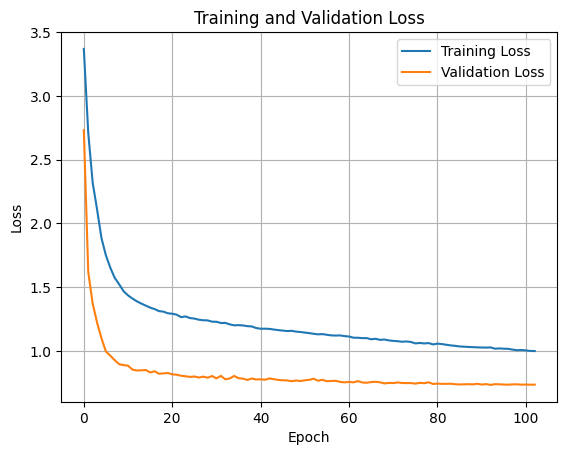

In [36]:
fig, ax = plt.subplots()
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid()
plt.savefig(f'models/kwt_{k}_{speech_commands_dataset_mode}_loss.svg', format='svg', bbox_inches='tight')

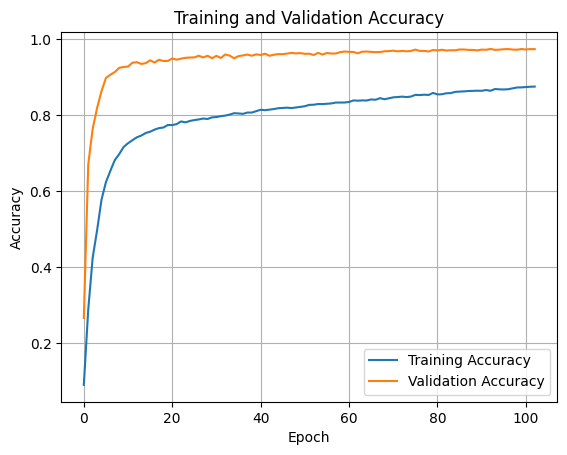

In [37]:
fig, ax = plt.subplots()
ax.plot(history.history['accuracy'], label='Training Accuracy')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax.set_title('Training and Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid()
plt.savefig(f'models/kwt_{k}_{speech_commands_dataset_mode}_accuracy.svg', format='svg', bbox_inches='tight')

In [38]:
test_loss, test_accuracy = model.evaluate(test_dataset)
test_loss, test_accuracy

22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 711ms/step - accuracy: 0.9688 - loss: 0.7437


(0.7436920404434204, 0.9688323736190796)

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step

I0000 00:00:1787756077.123461  407094 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_359552__.121


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step


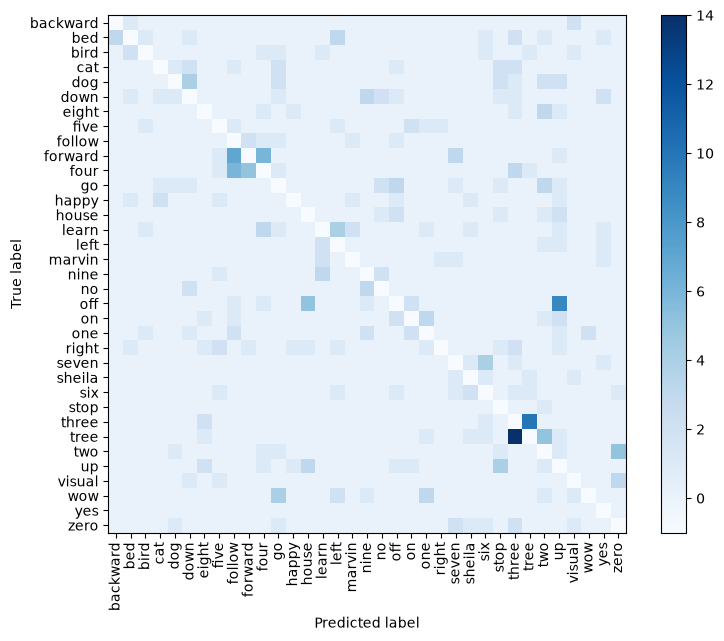

In [39]:
y_true = np.argmax(np.concatenate([y for _, y in test_dataset], axis=0), axis=-1)
y_pred = np.argmax(model.predict(test_dataset), axis=-1)

cm = metrics.confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, -1) # Fill diagonal with zeros to highlight errors

fig, ax = plt.subplots(figsize=[v*1.4 for v in plt.rcParams['figure.figsize']])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=speech_commands_dataset_manager.keywords)
display.plot(cmap='Blues', include_values=False, ax=ax, colorbar=True)
plt.xticks(rotation=90)
plt.savefig(f'models/kwt_{k}_{speech_commands_dataset_mode}_confusion_matrix.svg', format='svg', bbox_inches='tight')

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    shutil.copytree(
        src='/content/models',
        dst='/content/drive/MyDrive/Colab Notebooks/models',
        dirs_exist_ok=True
    )
    drive.flush_and_unmount()

Mounted at /content/drive


## Training with distillation

In [ ]:
if speech_commands_dataset_manager.mode != '35':
    raise ValueError("Distillation is only applicable for the '35' mode dataset")

In [ ]:
class TeacherModelWrapper: # Not used

    def __init__(self, sample_rate: int, pipeline: transformers.Pipeline) -> None:
        self.sample_rate = sample_rate
        self.pipeline = pipeline

    def __call__(self, batch_audio: tf.Tensor) -> tf.Tensor:
        batch_audio = batch_audio.numpy()
        inputs = [
            {'raw': batch_audio[i, :], 'sampling_rate': self.sample_rate}
            for i in range(batch_audio.shape[0])
        ]
        results = self.pipeline(inputs, batch_size=batch_audio.shape[0], top_k=1)
        keywords = [result[0]['label'] for result in results]
        return tf.constant(keywords, dtype=tf.string)

In [ ]:
def process_batch_distilled(
    mfcc_keyword: tuple[tf.Tensor, tf.Tensor],
    audio: tf.Tensor,
    teacher_model: TeacherModelWrapper
) -> tuple[tf.Tensor, tuple[tf.Tensor, tf.Tensor]]: # Not used
    mfcc, keyword = mfcc_keyword
    y = keyword_encoder(keyword)
    y_t = tf.py_function(
        func=lambda audio: keyword_encoder(teacher_model(audio)),
        inp=[audio],
        Tout=tf.int64
    )
    y_t.set_shape(y.shape)
    return mfcc, (y, y_t)

In [ ]:
cosine_decay = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    warmup_steps=warmup_steps
)
optimizer = keras.optimizers.AdamW(
    learning_rate=cosine_decay,
    weight_decay=weight_decay
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=f'models/kwt_{k}_distilled_{speech_commands_dataset_mode}.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
train_dataset_distilled = speech_commands_dataset_manager.build_dataset(split='train', batch_size=batch_size, return_teacher_keyword=True)
val_dataset_distilled = speech_commands_dataset_manager.build_dataset(split='val', batch_size=batch_size, return_teacher_keyword=True)
test_dataset_distilled = speech_commands_dataset_manager.build_dataset(split='test', batch_size=batch_size)

train_dataset_distilled = train_dataset_distilled.map(
    map_func=lambda mfcc_keyword, teacher_keyword: (mfcc_keyword[0], (keyword_encoder(mfcc_keyword[1]), keyword_encoder(teacher_keyword))),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset_distilled = val_dataset_distilled.map(
    map_func=lambda mfcc_keyword, teacher_keyword: (mfcc_keyword[0], (keyword_encoder(mfcc_keyword[1]), keyword_encoder(teacher_keyword))),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset_distilled = test_dataset_distilled.map(
    map_func=lambda mfcc, keyword: (mfcc, keyword_encoder(keyword)),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
model_distilled = KeywordTransformerDistilled(
    num_classes=len(speech_commands_dataset_manager.keywords),
    k=k,
    depth=depth
)

In [ ]:
model_distilled.compile(
    optimizer=optimizer,
    loss=[loss_function, loss_function],
    loss_weights=[0.5, 0.5],
    metrics=['accuracy', 'accuracy']
)
history_distilled = model_distilled.fit(
    train_dataset_distilled,
    validation_data=val_dataset_distilled,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint],
    shuffle=False
)

Epoch 1/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.0363 - accuracy_1: 0.0373 - categorical_crossentropy_loss: 3.5360 - loss: 3.5420 - val_accuracy: 0.0340 - val_accuracy_1: 0.0374 - val_categorical_crossentropy_loss: 3.5161 - val_loss: 3.5171
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.1040 - accuracy_1: 0.1011 - categorical_crossentropy_loss: 3.2809 - loss: 3.2800 - val_accuracy: 0.3536 - val_accuracy_1: 0.3388 - val_categorical_crossentropy_loss: 2.4589 - val_loss: 2.4727
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.2976 - accuracy_1: 0.2969 - categorical_crossentropy_loss: 2.6857 - loss: 2.6855 - val_accuracy: 0.6262 - val_accuracy_1: 0.6304 - val_categorical_crossentropy_loss: 1.7005 - val_loss: 1.7114
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.4148 - accuracy_1: 0.4163 - categorical_crossentropy_loss: 2.3414 - loss: 2.3430 - val_accuracy: 0.7452 - val_accuracy_1: 0.7463 - val_categorical_cross

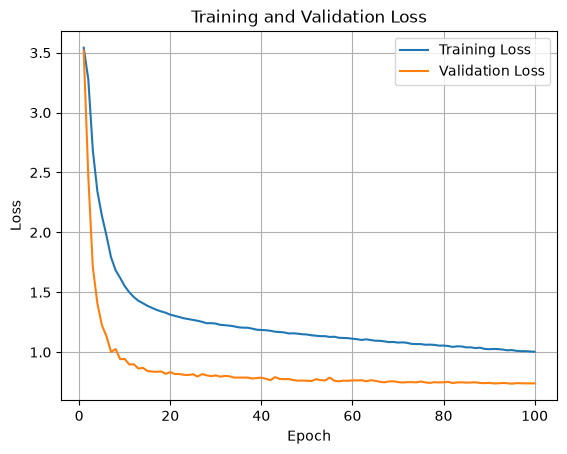

In [ ]:
fig, ax = plt.subplots()
ax.plot(history_distilled.history['loss'], label='Training Loss')
ax.plot(history_distilled.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid()
plt.savefig(f'models/kwt_{k}_distilled_{speech_commands_dataset_mode}_loss.svg', format='svg', bbox_inches='tight')

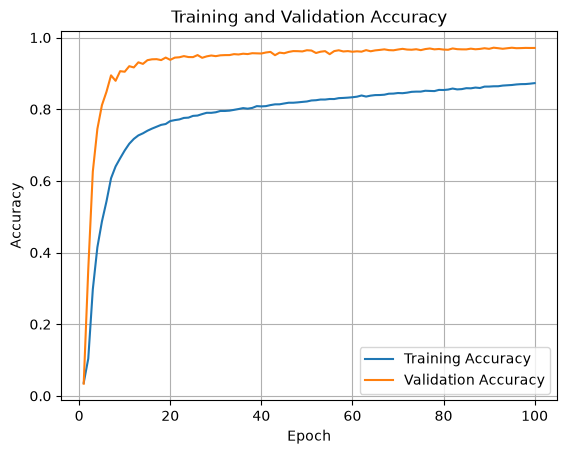

In [ ]:
fig, ax = plt.subplots()
ax.plot(history_distilled.history['accuracy'], label='Training Accuracy')
ax.plot(history_distilled.history['val_accuracy'], label='Validation Accuracy')
ax.set_title('Training and Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid()
plt.savefig(f'models/kwt_{k}_distilled_{speech_commands_dataset_mode}_accuracy.svg', format='svg', bbox_inches='tight')

In [34]:
class KeywordTransformerDistilledWrapper(keras.Model):

    def __init__(self, model: KeywordTransformerDistilled, **kwargs) -> None:
        super().__init__(**kwargs)
        self.model = model

    def call(self, mfccs: tf.Tensor, training: bool = None) -> tf.Tensor:
        class_logits, distillation_logits = self.model(mfccs, training=training)
        return (class_logits + distillation_logits) / 2.0

In [ ]:
model_distilled_wrapper = KeywordTransformerDistilledWrapper(model=model_distilled)
model_distilled_wrapper.compile(
    loss=loss_function,
    metrics=['accuracy']
)

In [ ]:
test_loss_distilled, test_accuracy_distilled = model_distilled_wrapper.evaluate(test_dataset_distilled)
test_loss_distilled, test_accuracy_distilled

22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9699 - loss: 0.7432


(0.7432445287704468, 0.9699227809906006)

21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step

I0000 00:00:1787756174.537320  407097 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_382122__.121


22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 304ms/step


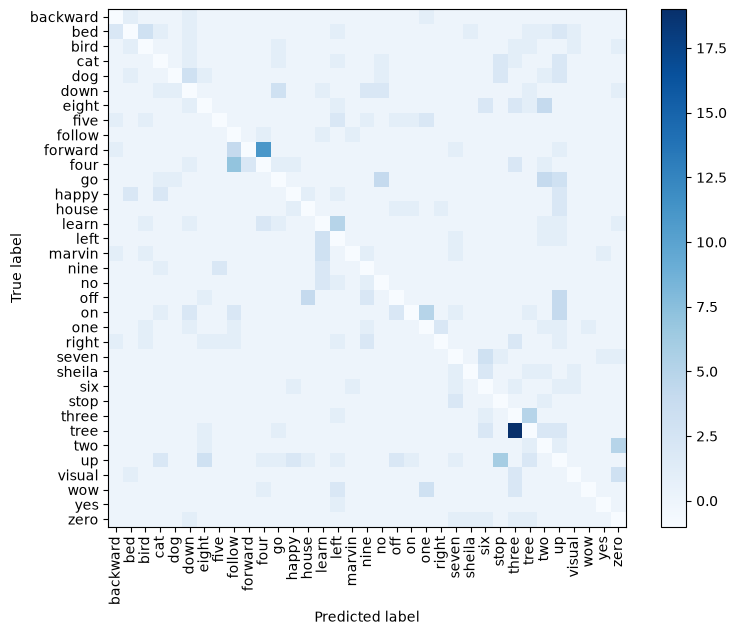

In [ ]:
y_true = np.argmax(np.concatenate([y for _, y in test_dataset_distilled], axis=0), axis=-1)
y_pred = np.argmax(model_distilled_wrapper.predict(test_dataset_distilled), axis=-1)

cm = metrics.confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, -1) # Fill diagonal with zeros to highlight errors

fig, ax = plt.subplots(figsize=[v*1.4 for v in plt.rcParams['figure.figsize']])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=speech_commands_dataset_manager.keywords)
display.plot(cmap='Blues', include_values=False, ax=ax, colorbar=True)
plt.xticks(rotation=90)
plt.savefig(f'models/kwt_{k}_distilled_{speech_commands_dataset_mode}_confusion_matrix.svg', format='svg', bbox_inches='tight')

In [ ]:
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    shutil.copytree(
        src='/content/models',
        dst='/content/drive/MyDrive/Colab Notebooks/models',
        dirs_exist_ok=True
    )
    drive.flush_and_unmount()

Mounted at /content/drive


## Training trigger

In [ ]:
# The outputs below were computed using the following parameter:
# - speech_commands_dataset_mode = '12'

In [173]:
if speech_commands_dataset_manager.mode != '12':
    raise ValueError("Trigger is only applicable for the '12' mode dataset")

In [ ]:
cosine_decay = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    warmup_steps=warmup_steps
)
optimizer = keras.optimizers.AdamW(
    learning_rate=cosine_decay,
    weight_decay=weight_decay
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience,
    restore_best_weights=True
)

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=f'models/kwt_trigger_{speech_commands_dataset_mode}.keras',
    monitor='val_loss',
    save_best_only=True
)

In [165]:
speech_commands_dataset_manager_trigger = SpeechCommandsDatasetManager(
    dataset_path=speech_commands_dataset_path,
    mode='2'
)

train_dataset_trigger = speech_commands_dataset_manager_trigger.build_dataset(split='train', batch_size=batch_size)
val_dataset_trigger = speech_commands_dataset_manager_trigger.build_dataset(split='val', batch_size=batch_size)
test_dataset_trigger = speech_commands_dataset_manager_trigger.build_dataset(split='test', batch_size=batch_size)

train_dataset_trigger = train_dataset_trigger.map(
    map_func=lambda mfcc, keyword: (mfcc, tf.cast(tf.equal(keyword, KNOWN_KEYWORD), tf.int32)),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset_trigger = val_dataset_trigger.map(
    map_func=lambda mfcc, keyword: (mfcc, tf.cast(tf.equal(keyword, KNOWN_KEYWORD), tf.int32)),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset_trigger = test_dataset_trigger.map(
    map_func=lambda mfcc, keyword: (mfcc, tf.cast(tf.equal(keyword, KNOWN_KEYWORD), tf.int32)),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
model_trigger = KeywordTransformer(
    num_classes=1,
    k=1,
    depth=depth // 2
)

In [167]:
loss_function_trigger = keras.losses.BinaryCrossentropy(
    from_logits=True,
    label_smoothing=label_smoothing
)

In [56]:
model_trigger.compile(
    optimizer=optimizer,
    loss=loss_function_trigger,
    metrics=['accuracy']
)
history_trigger = model_trigger.fit(
    train_dataset_trigger,
    validation_data=val_dataset_trigger,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint],
    shuffle=False
)

Epoch 1/383


I0000 00:00:1787841366.607274   83457 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_312796__.184


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6706 - loss: 0.6686

I0000 00:00:1787841383.099264   83455 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314522__.66
I0000 00:00:1787841387.022425   83456 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314522__.66


60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 321ms/step - accuracy: 0.6706 - loss: 0.6686 - val_accuracy: 0.6744 - val_loss: 0.6082
Epoch 2/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.6876 - loss: 0.5987 - val_accuracy: 0.6766 - val_loss: 0.5665
Epoch 3/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.6945 - loss: 0.5861 - val_accuracy: 0.7166 - val_loss: 0.5464
Epoch 4/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 237ms/step - accuracy: 0.7036 - loss: 0.5805 - val_accuracy: 0.7253 - val_loss: 0.5394
Epoch 5/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - accuracy: 0.7091 - loss: 0.5748 - val_accuracy: 0.7038 - val_loss: 0.5363
Epoch 6/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 261ms/step - accuracy: 0.7083 - loss: 0.5725 - val_accuracy: 0.7347 - val_loss: 0.5455
Epoch 7/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 350ms/step - accuracy: 0.7165 - loss: 0.5686 - val_accuracy: 0.7443 - val_loss: 0.5253
Epoch 8/383
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 223ms/step - accuracy: 0.7160 - loss: 0.5621 - val_accuracy

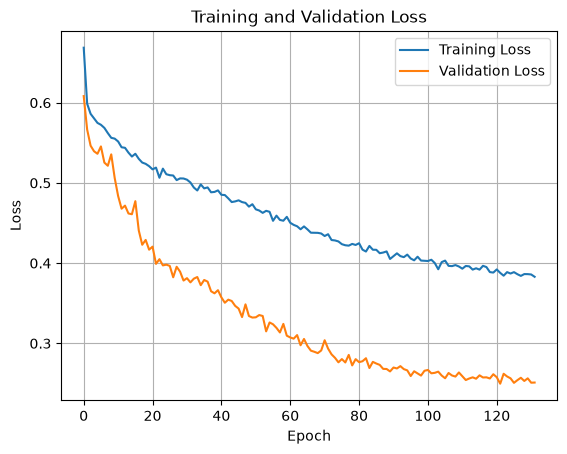

In [57]:
fig, ax = plt.subplots()
ax.plot(history_trigger.history['loss'], label='Training Loss')
ax.plot(history_trigger.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid()
plt.savefig(f'models/kwt_trigger_{speech_commands_dataset_mode}_loss.svg', format='svg', bbox_inches='tight')

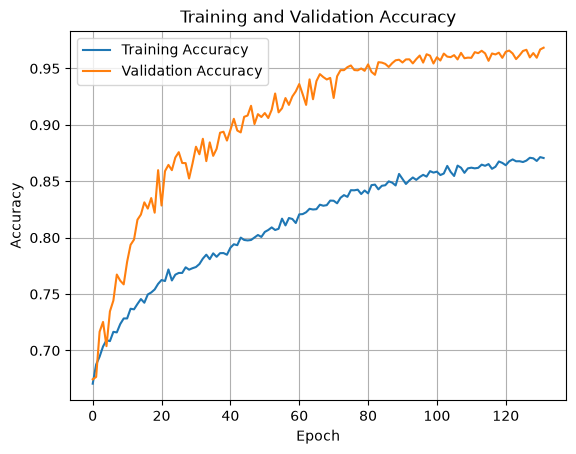

In [58]:
fig, ax = plt.subplots()
ax.plot(history_trigger.history['accuracy'], label='Training Accuracy')
ax.plot(history_trigger.history['val_accuracy'], label='Validation Accuracy')
ax.set_title('Training and Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid()
plt.savefig(f'models/kwt_trigger_{speech_commands_dataset_mode}_accuracy.svg', format='svg', bbox_inches='tight')

In [59]:
test_loss_trigger, test_accuracy_trigger = model_trigger.evaluate(test_dataset_trigger)
test_loss_trigger, test_accuracy_trigger

24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9583 - loss: 0.2635

I0000 00:00:1787843278.204450   83456 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314522__.66


25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.9590 - loss: 0.2622


(0.2622387111186981, 0.9590451717376709)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


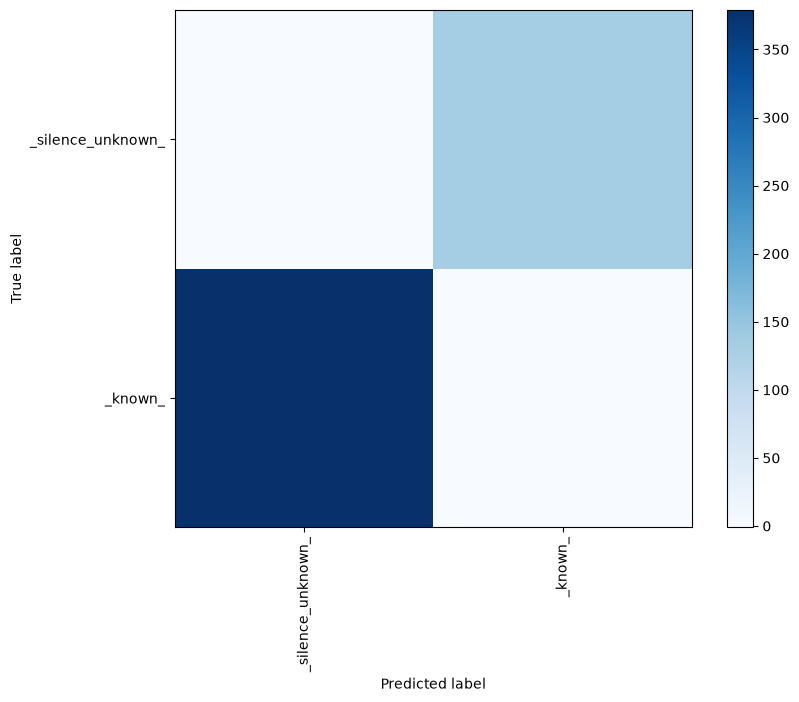

In [62]:
y_true = np.concatenate([y for _, y in test_dataset_trigger], axis=0)
y_pred = (model_trigger.predict(test_dataset_trigger) > 0.5).astype(np.int32).reshape(-1)

cm = metrics.confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, -1) # Fill diagonal with zeros to highlight errors

fig, ax = plt.subplots(figsize=[v*1.4 for v in plt.rcParams['figure.figsize']])
display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[SILENCE_UNKNOWN_KEYWORD, KNOWN_KEYWORD])
display.plot(cmap='Blues', include_values=False, ax=ax, colorbar=True)
plt.xticks(rotation=90)
plt.savefig(f'models/kwt_trigger_{speech_commands_dataset_mode}_confusion_matrix.svg', format='svg', bbox_inches='tight')

In [61]:
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    shutil.copytree(
        src='/content/models',
        dst='/content/drive/MyDrive/Colab Notebooks/models',
        dirs_exist_ok=True
    )
    drive.flush_and_unmount()